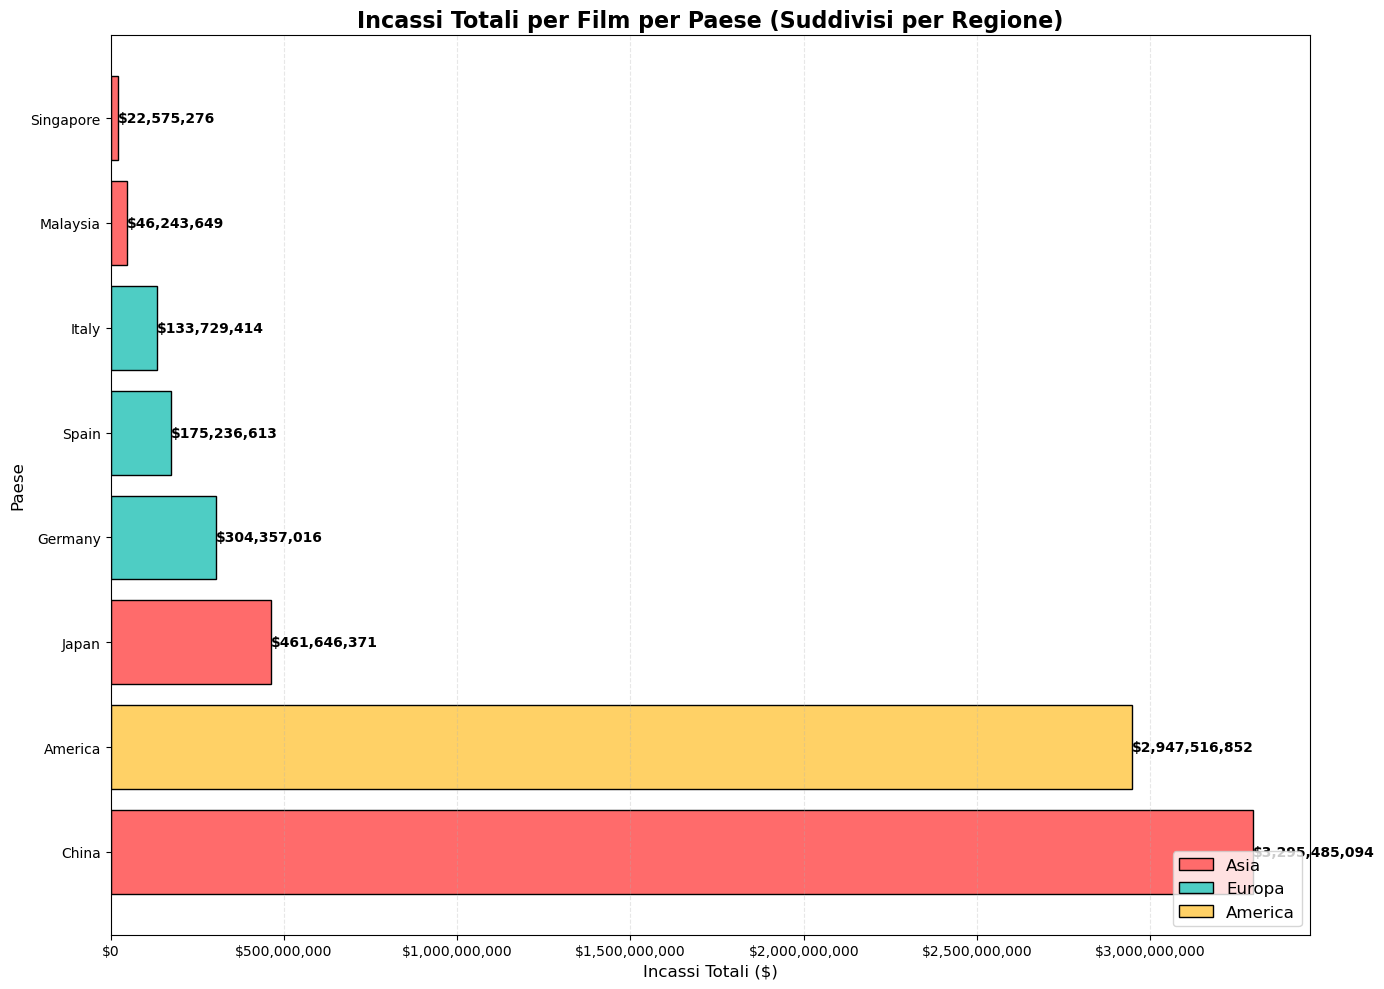

Incassi totali per paese (in ordine decrescente):
China: $3,295,485,094.00
America: $2,947,516,852.00
Japan: $461,646,371.00
Germany: $304,357,016.00
Spain: $175,236,613.00
Italy: $133,729,414.00
Malaysia: $46,243,649.00
Singapore: $22,575,276.00

Incassi totali per regione:
Asia: $3,825,950,390.00
Europa: $613,323,043.00
America: $2,947,516,852.00


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Carica il file CSV
df = pd.read_csv('Nazione - Foglio1 (1).csv', skiprows=1)

# Correzione dei nomi delle colonne
df.columns = ['Nome film', 'China', 'Singapore', 'Japan', 'Malaysia', 
              'America', 'Italy', 'Spain', 'Germany']

# Definisci i gruppi di paesi
asia_countries = ['China', 'Singapore', 'Japan', 'Malaysia']
europe_countries = ['Italy', 'Spain', 'Germany']
america_countries = ['America']

# Funzione per pulire i valori monetari e convertirli in float
def clean_currency(value):
    if isinstance(value, str):
        # Rimuovi $, virgole e spazi
        cleaned = value.replace('$', '').replace(',', '').strip()
        # Se c'è un trattino, restituisci 0
        if cleaned == '-':
            return 0
        try:
            return float(cleaned)
        except:
            return 0
    elif pd.isna(value):
        return 0
    return value

# Pulisci tutti i dati monetari
for country in df.columns[1:]:
    df[country] = df[country].apply(clean_currency)

# Calcola gli incassi totali per ogni paese
asia_totals = {country: df[country].sum() for country in asia_countries}
europe_totals = {country: df[country].sum() for country in europe_countries}
america_totals = {country: df[country].sum() for country in america_countries}

# Combina tutti i totali
all_totals = {**asia_totals, **europe_totals, **america_totals}

# Ordina i paesi per incassi totali (dal più alto al più basso)
sorted_countries = sorted(all_totals.items(), key=lambda x: x[1], reverse=True)
sorted_country_names = [country for country, total in sorted_countries]
sorted_totals = [total for country, total in sorted_countries]

# Definisci i colori per ogni regione
def get_country_color(country):
    if country in asia_countries:
        return '#FF6B6B'  # Rosso per Asia
    elif country in europe_countries:
        return '#4ECDC4'  # Turchese per Europa
    else:  # America
        return '#FFD166'  # Giallo per America

colors = [get_country_color(country) for country in sorted_country_names]

# Crea il grafico
plt.figure(figsize=(14, 10))

# Crea l'istogramma orizzontale
bars = plt.barh(sorted_country_names, sorted_totals, color=colors, edgecolor='black')

# Aggiungi le etichette dei valori
for bar, value in zip(bars, sorted_totals):
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2, 
             f'${value:,.0f}', 
             ha='left', va='center', fontweight='bold')

# Aggiungi titolo e etichette
plt.title('Incassi Totali per Film per Paese (Suddivisi per Regione)', fontsize=16, fontweight='bold')
plt.xlabel('Incassi Totali ($)', fontsize=12)
plt.ylabel('Paese', fontsize=12)

# Aggiungi una legenda per le regioni
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#FF6B6B', edgecolor='black', label='Asia'),
    Patch(facecolor='#4ECDC4', edgecolor='black', label='Europa'),
    Patch(facecolor='#FFD166', edgecolor='black', label='America')
]
plt.legend(handles=legend_elements, loc='lower right', fontsize=12)

# Formatta l'asse x con i valori monetari
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# Imposta il layout
plt.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()

# Mostra il grafico
plt.show()

# Opzionale: stampa i valori totali per controllo
print("Incassi totali per paese (in ordine decrescente):")
for country, total in sorted_countries:
    print(f"{country}: ${total:,.2f}")

# Opzionale: incassi totali per regione
print("\nIncassi totali per regione:")
print(f"Asia: ${sum(asia_totals.values()):,.2f}")
print(f"Europa: ${sum(europe_totals.values()):,.2f}")
print(f"America: ${sum(america_totals.values()):,.2f}")